# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
174,0.016281,0.050680,0.009961,-0.043542,-0.096510,-0.094632,-0.039719,-0.039493,0.017036,0.007207,151.0
411,0.005383,-0.044642,0.058463,-0.043542,-0.073119,-0.072399,0.019187,-0.076395,-0.051404,-0.025930,136.0
185,-0.074533,0.050680,-0.018062,0.008101,-0.019456,-0.024800,-0.065491,0.034309,0.067318,-0.017646,101.0
340,-0.016412,-0.044642,-0.013751,0.132044,-0.009825,-0.003819,0.019187,-0.039493,-0.035816,-0.030072,216.0
325,-0.001882,-0.044642,0.054152,-0.066506,0.072732,0.056619,-0.043401,0.084863,0.084492,0.048628,192.0
153,0.041708,0.050680,-0.043929,0.063187,-0.004321,0.016222,-0.013948,-0.002592,-0.034522,0.011349,71.0
71,-0.001882,-0.044642,0.033673,0.125158,0.024574,0.026243,-0.010266,-0.002592,0.026717,0.061054,270.0
207,0.009016,-0.044642,0.045529,0.028758,0.012191,-0.013840,0.026550,-0.039493,0.046133,0.036201,202.0
103,0.059871,0.050680,0.041218,0.011544,0.041086,0.070710,-0.036038,0.034309,-0.010903,-0.030072,198.0
376,-0.001882,-0.044642,0.068163,-0.005670,0.119515,0.130208,-0.024993,0.086708,0.046133,-0.001078,121.0


In [10]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [13]:
print(data[['bmi', 'bp']].isnull().sum())

bmi    44
bp     44
dtype: int64


### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [ ]:
simple_imp = SimpleImputer(strategy='mean')  # o 'median', 'most_frequent'

data_simple = data.copy()
data_simple[['bmi', 'bp']] = simple_imp.fit_transform(data[['bmi', 'bp']])

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [15]:
knn_imp = KNNImputer(n_neighbors=5)

data_knn = data.copy()
data_knn[['bmi', 'bp']] = knn_imp.fit_transform(data[['bmi', 'bp']])

### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

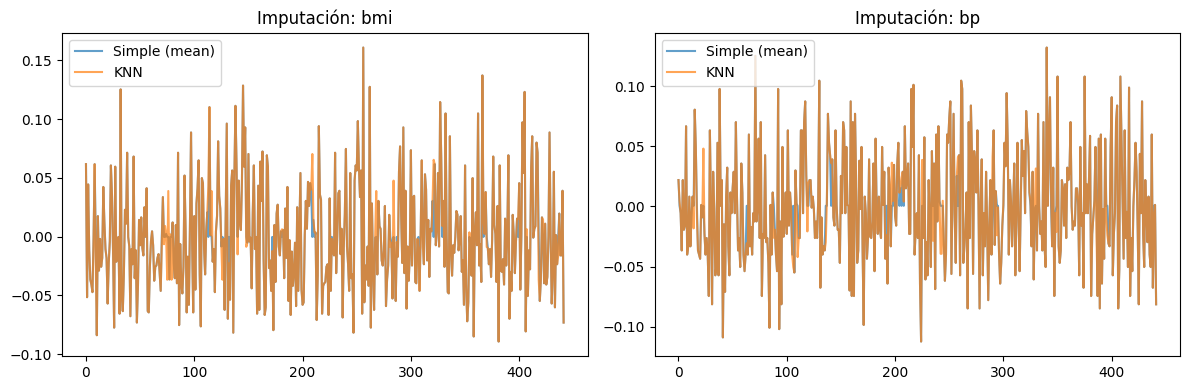

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['bmi', 'bp']):
    ax.plot(data_simple[col].values, label='Simple (mean)', alpha=0.7)
    ax.plot(data_knn[col].values, label='KNN', alpha=0.7)
    ax.set_title(f'Imputación: {col}')
    ax.legend()

plt.tight_layout()
plt.show()